In [1]:
from sentence_transformers import SentenceTransformer

model=SentenceTransformer("all-MiniLM-L6-v2")

sentence =  "This is the practice of attention is all you need and it is one of the best papers"

embeddings = model.encode(sentence)
embeddings

c:\Users\itsra\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([ 3.83604947e-03,  8.35649818e-02, -4.62882308e-04, -8.57069995e-03,
        1.19209159e-02,  1.92636140e-02, -4.30186046e-03, -7.91984331e-03,
        3.21099013e-02,  3.03656198e-02,  9.86755732e-03,  7.41530508e-02,
       -1.83351841e-02, -1.50833733e-03, -3.08203977e-02,  1.09536583e-02,
        1.87104903e-02, -3.15897353e-03, -3.55117992e-02,  4.56754640e-02,
        1.29512018e-02, -2.10590195e-02,  7.54378363e-02, -6.05235919e-02,
       -7.63107389e-02, -2.93820119e-03, -8.69825259e-02, -1.04818620e-01,
        4.09741178e-02, -2.09356882e-02,  4.88811210e-02,  6.62924275e-02,
        5.41756190e-02,  8.40715617e-02, -2.49409657e-02,  7.56566375e-02,
       -2.86638737e-02,  3.60164046e-02,  2.82571018e-02, -9.21751373e-03,
        7.99863692e-03, -3.22423130e-02,  8.55185557e-04, -2.60145981e-02,
        5.73259071e-02, -2.09019072e-02, -3.40415165e-02,  2.11106893e-02,
       -6.14029216e-03, -6.87994808e-02, -1.39794230e-01, -1.27186760e-01,
       -7.63336420e-02,  

In [2]:
embeddings.shape

(384,)

this means that the embeddings are represented in 384 vector space.
any word of the sentence will also be represented in that dim only.

In [3]:
from sentence_transformers import util

sentence2="The 'Attention Is All You Need' paper is a seminal work in AI, introducing the transformer architecture that revolutionized the field"

sentence3="India is a great and very culturally rich country"


embeddings2=model.encode(sentence2)
embeddings3=model.encode(sentence3)
similarity1=util.cos_sim(embeddings,embeddings2)
similarity2=util.cos_sim(embeddings,embeddings3)

print(similarity1,similarity2)

tensor([[0.5471]]) tensor([[0.0856]])


we can notice that the sentence 1 and 2 are more similar than 1 n 3.

Word2Vec generates static, context-independent word embeddings, mapping each word to a single vector. In contrastSentence Transformers (SBERT) produce dynamic, context-aware sentence or document embeddings, capturing nuanced semantic meaning, word order, and polysemy. Word2Vec is faster and better for resource-limited, word-level tasks, whereas Sentence Transformers are superior for search, clustering, and semantic similarity

In [4]:
from transformers import AutoTokenizer, AutoModel
import numpy as np
import torch
from math import sqrt

In [5]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
auto_model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = auto_model(**inputs)

X_sen1 = outputs.last_hidden_state.squeeze(0).numpy()

In [6]:
import numpy as np

np.random.seed(42)

input_dim = 384
d_k = 32
d_v = 32
W_q=np.random.randn(input_dim,d_k)
W_k = np.random.randn(input_dim, d_k)
W_v = np.random.randn(input_dim, d_v)

Q = X_sen1 @ W_q
K = X_sen1 @ W_k
V = X_sen1 @ W_v

Q, K, V

(array([[-3.99977562e+00, -1.21666774e+00, -3.83314832e+00,
          4.94916717e+00, -1.57875166e+00,  3.13655042e+00,
          2.97351520e+00, -3.59422374e+00, -4.73436485e+00,
         -3.27077973e+00,  4.14308753e+00,  4.51721311e+00,
          1.39463015e+01,  4.94772600e+00, -3.65463298e+00,
          5.19305454e-01, -4.80905385e+00,  1.48680386e+00,
         -2.85285224e+00,  6.08000020e+00, -1.90405522e+00,
          1.23661799e+01,  1.52244979e+00,  4.79820509e+00,
          1.26357936e+01, -9.67346465e+00,  1.16634359e+00,
         -1.02607781e+01, -2.74755812e-01, -1.80440222e+01,
         -1.26306486e+00,  3.09435569e+00],
        [-5.04387906e+00,  1.18307416e+00,  2.93699882e+00,
         -1.84721227e+00, -1.77559634e+00, -1.93975761e+01,
         -5.83412638e-01, -9.32313032e+00,  9.55026070e+00,
          4.83375966e+00,  3.22288570e+00,  7.42018211e+00,
          1.67339966e+01,  3.15833331e+00,  1.54969962e+01,
         -2.99829784e+00,  8.87280907e+00, -2.69665258e+

In [7]:
scores = Q @ K.T
scores = scores / sqrt(d_k)

scores_exp = np.exp(scores - np.max(scores, axis=1, keepdims=True))
attention_weights = scores_exp / np.sum(scores_exp, axis=1, keepdims=True)

output = attention_weights @ V

In [8]:
# print(scores[i])

Token embeddings
        ↓
Linear projections (Q, K, V)
        ↓
Scaled dot-product attention
        ↓
New token representations

In [9]:
output

array([[ -2.39132106, -21.53935945, -17.03248645,  10.44153969,
          2.66472281,  -3.07096763,   2.10438281,  18.01307129,
          7.60943924,  39.07772256,  -7.8198912 ,  19.08805733,
         11.66752942,  25.25181225,  -0.39015384,  -1.18554832,
        -35.37312855,  -5.07233916,  12.12604968,  -8.35840996,
        -12.3196862 ,  -1.75755719, -22.70165979,  17.67757652,
          5.40707527,   5.70963915,   5.28629447,   1.25873607,
        -13.67739627, -25.62029465,  13.68679926,   5.88690812],
       [ -6.12526467,   3.85426687, -13.09063053, -17.954327  ,
         17.69635314,  -5.223504  , -17.03438238,  -4.44379767,
          1.21642679,  12.00603873,   7.17045761,  12.04536009,
         -4.9749822 ,  17.99218578,   1.5453318 ,  15.34871033,
         -5.20878055,  -5.39228915,  -4.74172839,   0.3756859 ,
         17.73621006,  -5.16010364, -11.71054755,   7.66398014,
          7.07544263,  -2.27192305, -21.27038462, -23.33898734,
          1.90259491,   4.95562525,  17

In [10]:
attention_weights

array([[3.27399363e-053, 6.46047392e-073, 6.83315449e-055,
        6.44392591e-051, 3.03666417e-066, 1.50309125e-058,
        3.72153403e-137, 3.64871963e-060, 1.03093704e-057,
        3.78798049e-056, 9.26862817e-075, 8.43465373e-048,
        3.13090184e-047, 2.23708960e-053, 1.44769103e-068,
        2.39752101e-065, 6.54138903e-055, 2.85210041e-083,
        1.00000000e+000, 2.43261888e-068],
       [1.76673084e-087, 7.50704075e-083, 2.93366361e-082,
        1.07162792e-077, 2.50914822e-093, 6.53059806e-083,
        1.00000000e+000, 2.19007435e-088, 1.70153650e-093,
        3.72092919e-091, 1.51047892e-082, 2.88712777e-073,
        3.85687653e-077, 8.37853000e-081, 1.66933491e-081,
        1.36325599e-076, 4.81605076e-079, 1.20271339e-088,
        8.10442002e-118, 1.64529287e-129],
       [4.63057305e-035, 5.31585702e-035, 1.95218805e-031,
        7.53900105e-029, 5.82321143e-033, 1.21391377e-030,
        1.00000000e+000, 5.20493516e-031, 1.56703876e-030,
        6.29444895e-038, 8.13

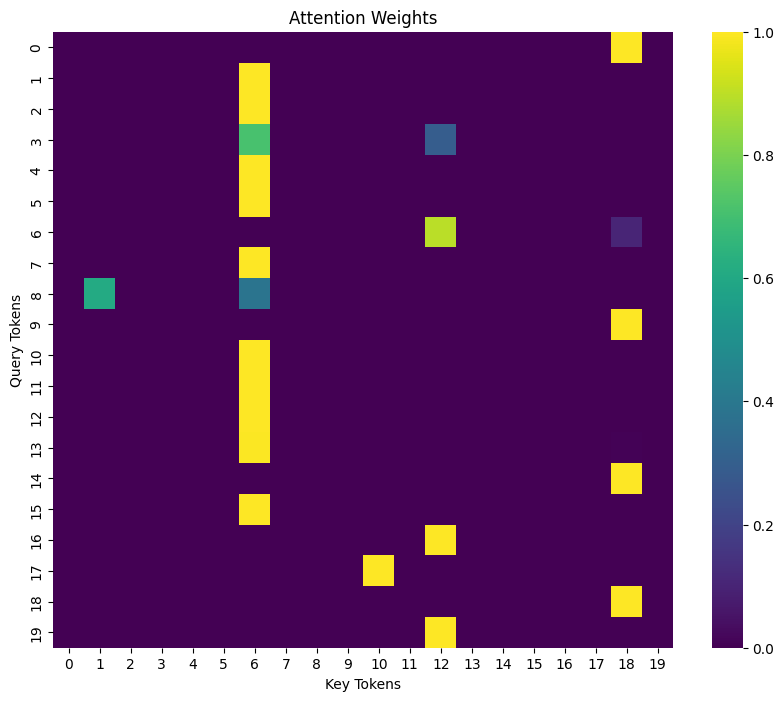

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

weights = attention_weights  # (seq_len, seq_len)

plt.figure(figsize=(10,8))
sns.heatmap(weights, cmap="viridis")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Attention Weights")
plt.show()

In [12]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(tokens)

['[CLS]', 'this', 'is', 'the', 'practice', 'of', 'attention', 'is', 'all', 'you', 'need', 'and', 'it', 'is', 'one', 'of', 'the', 'best', 'papers', '[SEP]']


In [13]:
print(len(tokens), attention_weights.shape)

20 (20, 20)


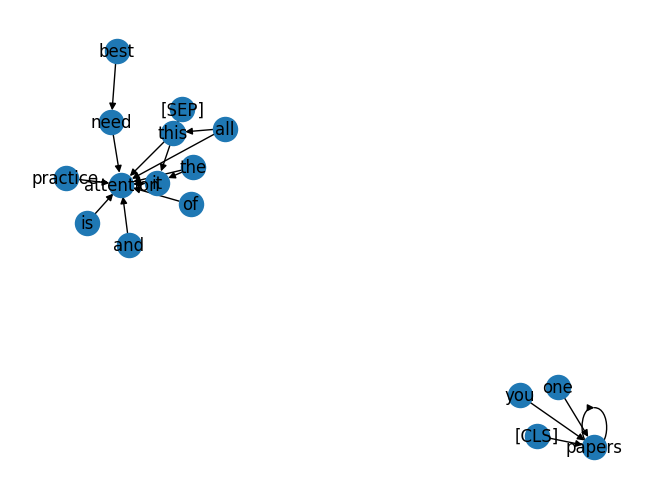

In [14]:
import networkx as nx

G = nx.DiGraph()

threshold = 0.2
for i in range(len(tokens)):
    for j in range(len(tokens)):
        if attention_weights[i,j] > threshold:
            G.add_edge(tokens[i], tokens[j],
                       weight=attention_weights[i,j])

nx.draw(G, with_labels=True)
plt.show()

In [15]:
i = tokens.index("it")
print(i)

12


In [16]:
attention_weights[i]

array([9.73552494e-44, 9.50207392e-19, 7.91908067e-28, 5.34595805e-25,
       1.84790296e-15, 8.49472228e-25, 1.00000000e+00, 1.51799815e-28,
       8.90057009e-28, 8.14579085e-31, 4.02973815e-21, 1.29329036e-22,
       2.99465235e-12, 1.09150473e-23, 1.83906686e-28, 1.78939429e-23,
       3.90887694e-23, 3.46934382e-27, 3.04727290e-22, 1.25521184e-38])

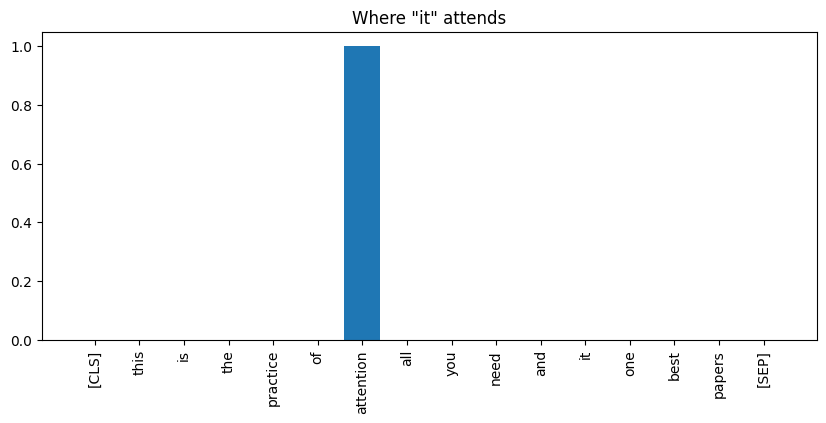

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(tokens, attention_weights[i])
plt.xticks(rotation=90)
plt.title('Where "it" attends')
plt.show()

In [18]:
import numpy as np

row = attention_weights[i]
top_indices = np.argsort(row)[-5:][::-1]

print('Top tokens "it" attends to:\n')
for idx in top_indices:
    print(f"{tokens[idx]} -> {row[idx]:.4f}")

Top tokens "it" attends to:

attention -> 1.0000
it -> 0.0000
practice -> 0.0000
this -> 0.0000
need -> 0.0000


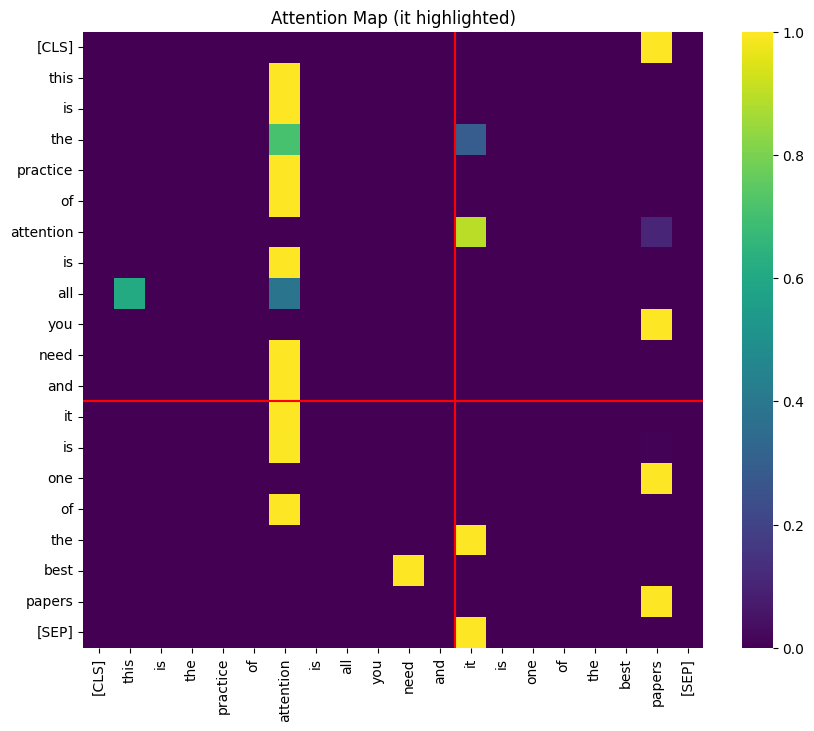

In [19]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(attention_weights,
            xticklabels=tokens,
            yticklabels=tokens,
            cmap="viridis")

plt.axhline(i, color='red')  # highlight row
plt.axvline(i, color='red')  # highlight column
plt.xticks(rotation=90)
plt.title('Attention Map (it highlighted)')
plt.show()

In [20]:
print(np.round(attention_weights[i], 4))

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [21]:
from scipy.stats import entropy
import numpy as np

print("Entropy:", entropy(attention_weights[i]))
print("Max possible entropy:", np.log(len(tokens)))

Entropy: 8.251990440919122e-11
Max possible entropy: 2.995732273553991
